Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library('tidymodels')



── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.9     ✔ recipes      1.3.1
✔ dials        1.4.2     ✔ rsample      1.3.1
✔ dplyr        1.1.4     ✔ tailor       0.1.0
✔ ggplot2      3.5.2     ✔ tidyr        1.3.1
✔ infer        1.0.9     ✔ tune         2.0.0
✔ modeldata    1.5.1     ✔ workflows    1.3.0
✔ parsnip      1.3.3     ✔ workflowsets 1.1.1
✔ purrr        1.1.0     ✔ yardstick    1.3.2

── Conflicts ────────────────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [3]:
glimpse(diabetes_train)



Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 1, 5, 4, 10, 1, 3, 8, 5, 5, 3, 10, 4, 11, …
$ Glucose                  <dbl> 85, 89, 116, 110, 139, 103, 126, 99, 117, 109…
$ BloodPressure            <dbl> 66, 66, 74, 92, 80, 30, 88, 84, 92, 75, 58, 7…
$ SkinThickness            <dbl> 29, 23, 0, 0, 0, 38, 41, 0, 0, 26, 11, 31, 33…
$ Insulin                  <dbl> 0, 94, 0, 0, 0, 83, 235, 0, 0, 0, 54, 0, 192,…
$ BMI                      <dbl> 26.6, 28.1, 25.6, 37.6, 27.1, 43.3, 39.3, 35.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.167, 0.201, 0.191, 1.441, 0.183, 0.7…
$ Age                      <dbl> 31, 21, 30, 30, 57, 33, 27, 50, 38, 60, 22, 4…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

The variable suited as the "Outcome" column in a logistic regression model would be whether an individual does or does not have diabetes. 

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
| BMI         | Body mass index (weight in kg/(height in m)^2)            |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

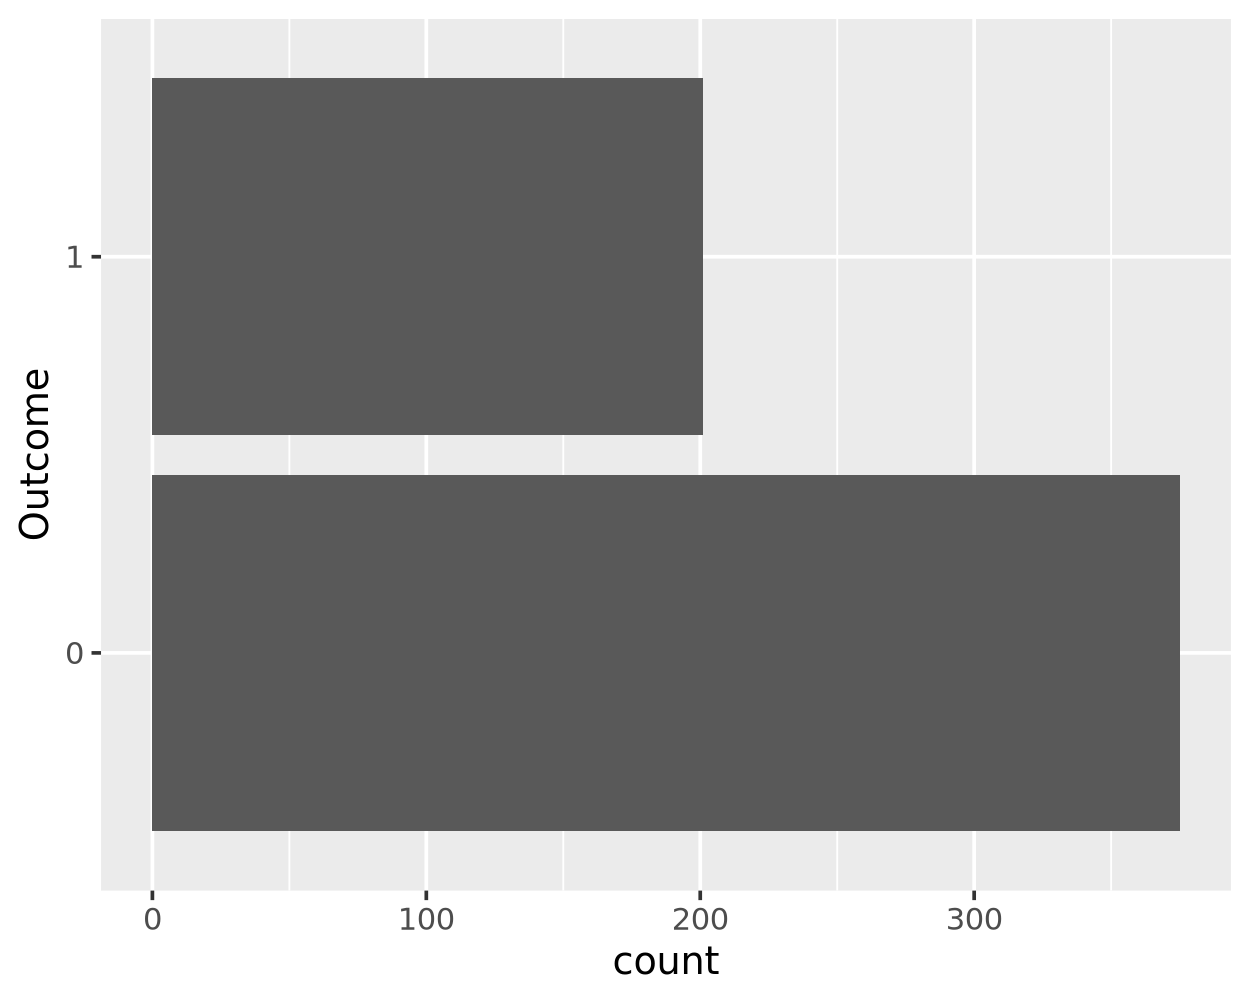

In [4]:
ggplot(diabetes_train, aes(y = Outcome)) + geom_bar()

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

It appears that the data is not balanced, and that the count for the Outcome value of 0 is higher than the Outcome value 1.



Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [5]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

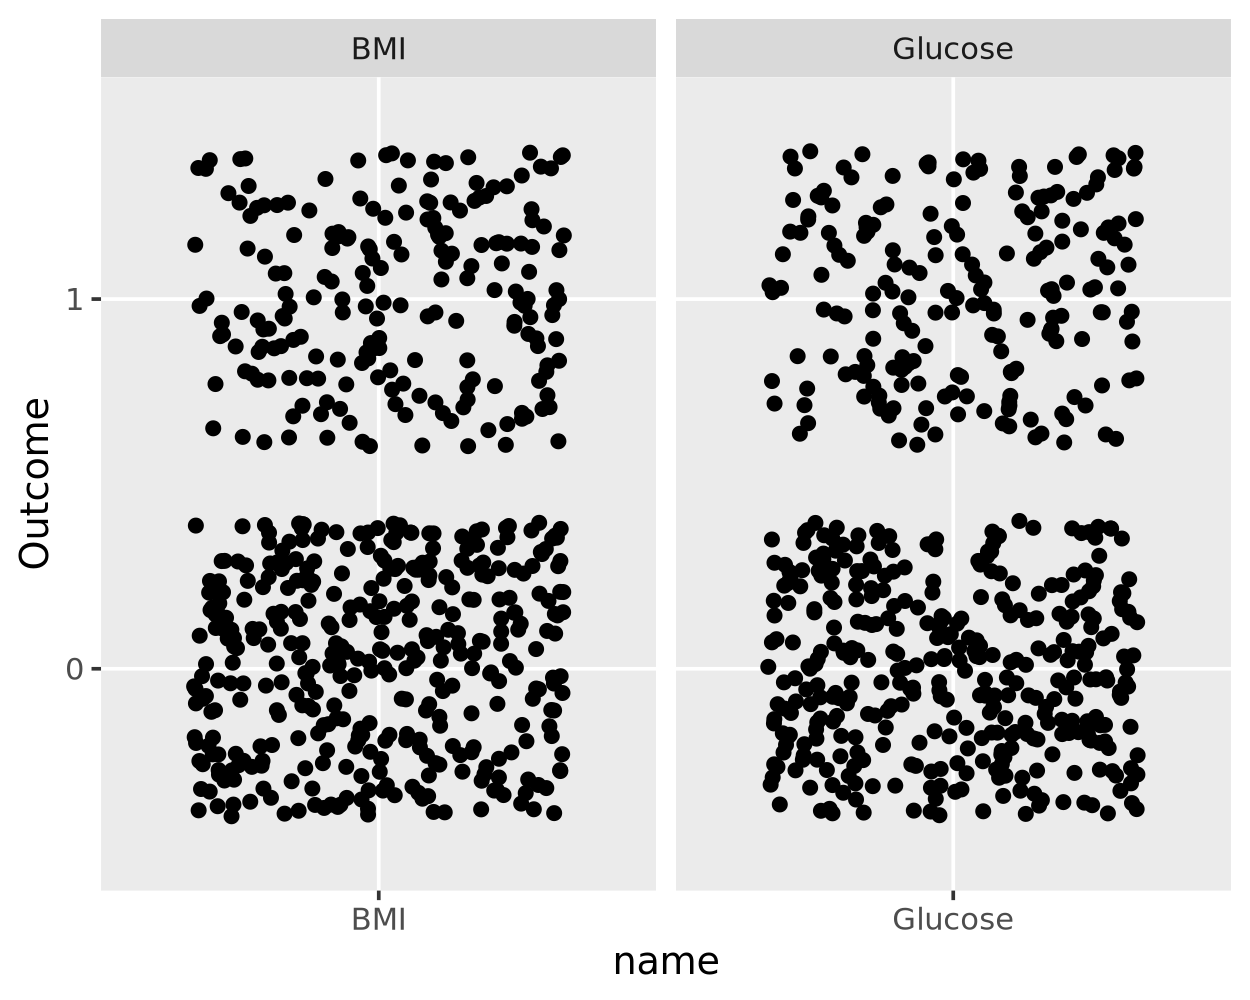

In [7]:
ggplot(plot_df, aes(y = Outcome, x = name)) +
    geom_jitter() +
    facet_wrap(~name, ncol = 2, scales = 'free_x')



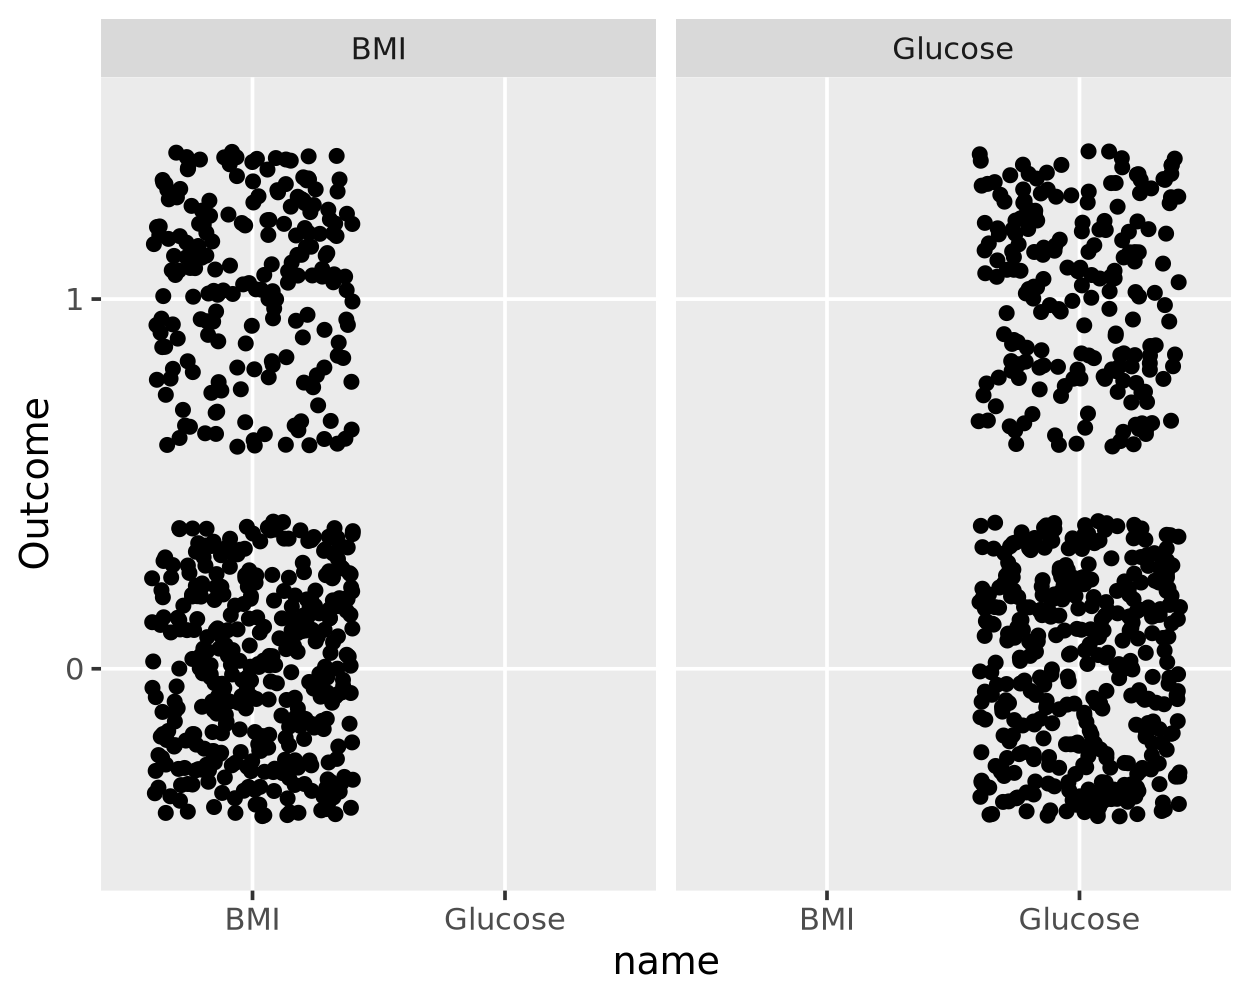

In [8]:
ggplot(plot_df, aes(y = Outcome, x = name)) +
    geom_jitter() +
    facet_wrap(~name, ncol = 2)

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

It appears that the scales = 'free_x' argument removes the unnecessary/redundant 'Glucose' and 'BMI' labels on the x-axis of our visualized plot that contain empty values, which wouldn't be useful in our visualization. 

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [9]:
#Creating logistic regression model
mod = logistic_reg() |> set_engine('glm')

mod

Logistic Regression Model Specification (classification)

Computational engine: glm 


In [10]:
#Fitting/training our model
mod_fit = mod |> fit(Outcome ~ BMI + Glucose, diabetes_train)

tidy(mod_fit)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-7.42833268,0.686646044,-10.818285,2.820045e-27
BMI,0.07626827,0.015093830,5.052944,4.350517e-07
Glucose,0.03434977,0.003744513,9.173363,4.584861e-20


Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [14]:
diabetes_test_wPred = augment(mod_fit, diabetes_test)

head(diabetes_test_wPred)

.pred_class,.pred_0,.pred_1,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,0.3624493,0.6375507,0,137,40,35,168,43.1,2.288,33,1
0,0.6869371,0.3130629,10,115,0,0,0,35.3,0.134,29,0
1,0.1591247,0.8408753,2,197,70,45,543,30.5,0.158,53,1
1,0.2243274,0.7756726,10,168,74,0,0,38.0,0.537,34,1
1,0.2043298,0.7956702,1,189,60,23,846,30.1,0.398,59,1
0,0.6983023,0.3016977,1,115,70,30,96,34.6,0.529,32,1


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [15]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 114  34
         1  11  33

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

When looking at our "Truth" columns according to our confusion matrix, the total number of individuals that did have diabetes was 33+34 = 67. When our model predicted individual having diabetes, the number of individuals that did have diabetes was 33 out of the 67. When our model predicted individuals to have diabetes, the number of individuals that did not actually have diabetes was 11. 

